In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

2024-06-08 09:44:53.153521: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-08 09:44:53.156638: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-06-08 09:44:53.194661: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-08 09:44:54.124461: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:




#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/Dataset/dataset_training_no_aug.h5"
#"/workspaces/work/Dataset/dataset_training_no_aug.h5"



In [3]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,5000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [4]:
data = awgn(data, snr_range)

In [ ]:
print(data)

In [5]:
import numpy as np

def apply_random_shift(data, max_shift):
    shift = np.random.randint(-max_shift, max_shift + 1)
    return np.roll(data, shift, axis=1)

def apply_random_noise(data, noise_level):
    noise = np.random.normal(scale=noise_level, size=data.shape)
    return data + noise

# Example usage
max_shift = 10
noise_level = 0.1

# Apply random shift and noise to a single sample
augmented_sample = apply_random_shift(data, max_shift)
augmented_sample = apply_random_noise(augmented_sample, noise_level)


(5000, 8192)

In [5]:
data.shape

(5000, 8192)

/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/codespace/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


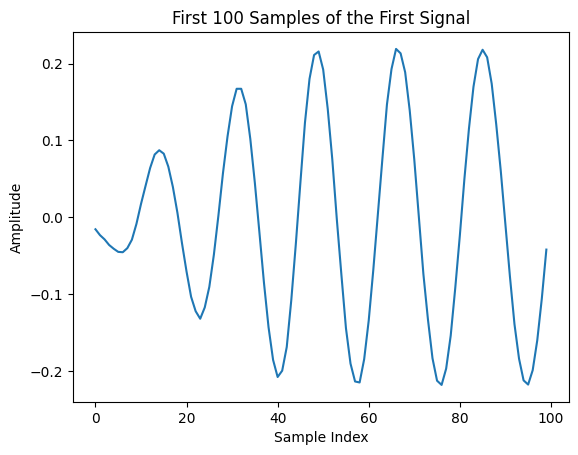

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Example data (replace this with your actual data)
data = data  # Simulated data

# Plot the first few samples of the first signal
plt.plot(data[0, :100])
plt.title('First 100 Samples of the First Signal')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.show()

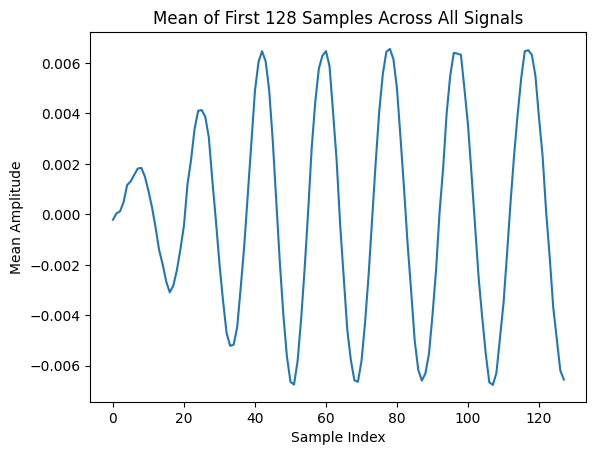

Suspected Preamble: [-2.12185830e-04+8.63016431e-04j  3.63059056e-05+1.09735782e-03j
  1.20940739e-04+1.07389248e-03j  4.88309540e-04+1.16071616e-03j
  1.16068440e-03+9.63077297e-04j  1.30658286e-03+9.10245017e-04j
  1.56733899e-03+3.49697668e-04j  1.81686739e-03-2.71405203e-05j
  1.83961409e-03-7.29490903e-04j  1.49509176e-03-1.33895403e-03j
  9.30587646e-04-1.79937004e-03j  2.77606326e-04-2.27991699e-03j
 -5.13805890e-04-2.47879713e-03j -1.41017051e-03-2.02441781e-03j
 -1.97889096e-03-1.75577277e-03j -2.66167516e-03-8.54071241e-04j
 -3.08893699e-03+4.09541441e-04j -2.82418614e-03+1.17209551e-03j
 -2.21751178e-03+2.38690953e-03j -1.38272020e-03+3.12237599e-03j
 -4.43681817e-04+3.66902224e-03j  1.19814133e-03+3.49941492e-03j
  2.15689799e-03+2.90928933e-03j  3.39339814e-03+1.94732173e-03j
  4.10252430e-03+7.56929835e-04j  4.13193860e-03-6.83688519e-04j
  3.86314774e-03-2.00251712e-03j  3.05555800e-03-3.49861761e-03j
  1.33768518e-03-4.50511579e-03j -2.52128347e-04-4.92611685e-03j
 -1.9

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is a NumPy array with shape (30000, 8192)

# Calculate the mean of the first 128 samples across all signals to detect a common pattern
N = 128  # Length of the suspected preamble
mean_pattern = np.mean(data[:, :N], axis=0)

# Plot the mean pattern to visually inspect it
plt.plot(mean_pattern)
plt.title('Mean of First 128 Samples Across All Signals')
plt.xlabel('Sample Index')
plt.ylabel('Mean Amplitude')
plt.show()

# Output the suspected preamble
suspected_preamble = mean_pattern
print("Suspected Preamble:", suspected_preamble)


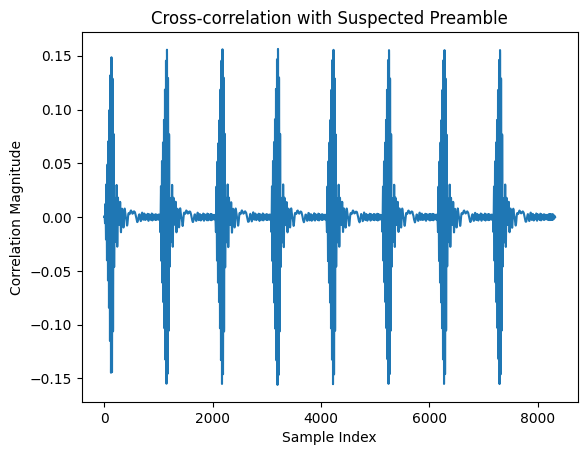

Peak correlation index: 3201
Peak correlation value: (-0.027405689958279356+0.1557397026804165j)
Synchronized signal start index: 3074


In [8]:
# Example: Cross-correlation to verify the suspected preamble

# Use the first signal for cross-correlation
received_signal = data[0]

# Perform cross-correlation
correlation = np.correlate(received_signal, suspected_preamble, mode='full')
peak_index = np.argmax(np.abs(correlation))

# Plot the correlation result
plt.plot(correlation)
plt.title('Cross-correlation with Suspected Preamble')
plt.xlabel('Sample Index')
plt.ylabel('Correlation Magnitude')
plt.show()

# Output the index of the maximum correlation value
print(f"Peak correlation index: {peak_index}")
print(f"Peak correlation value: {correlation[peak_index]}")

# Check if the peak is significant and verify the preamble
start_index = peak_index - len(suspected_preamble) + 1
synchronized_signal = received_signal[start_index:]

print(f"Synchronized signal start index: {start_index}")


In [10]:
import numpy as np

# Given values
peak_index =3201
preamble_length = 128  # Assuming preamble length, adjust as needed
start_index = peak_index - preamble_length + 1

# Example received signal (replace with actual data)
received_signal = data[0]  # Using the first signal for illustration

# Extract the suspected preamble from the synchronized signal
suspected_preamble = received_signal[start_index:start_index + preamble_length]

print("Suspected Preamble:", suspected_preamble)
print("Synchronized signal start index:", start_index)


Suspected Preamble: [-0.17863837+0.12582058j -0.1727543 +0.13151032j -0.15629663+0.15098285j
 -0.1339791 +0.17446631j -0.10195124+0.19291249j -0.06016122+0.20749445j
 -0.0094912 +0.22035596j  0.04825779+0.21424957j  0.10136641+0.19214641j
  0.15676206+0.15377647j  0.19430749+0.0996067j   0.2166225 +0.03615138j
  0.21555585-0.03599064j  0.19369551-0.10296536j  0.14908168-0.16164334j
  0.08672629-0.20296556j  0.01058787-0.21957278j -0.06557278-0.20995121j
 -0.13299572-0.1750778j  -0.18477222-0.11915859j -0.21269564-0.04632758j
 -0.21607393+0.03301363j -0.19082778+0.10671991j -0.13837254+0.16975598j
 -0.07315022+0.20871046j  0.0037488 +0.21850691j  0.08283936+0.20426752j
  0.15457178+0.15850542j  0.19874302+0.09406529j  0.21766305+0.01421397j
  0.21192574-0.06468477j  0.17423461-0.13499318j  0.11224792-0.18768005j
  0.04350682-0.2149128j  -0.03597604-0.21776286j -0.11560543-0.1881006j
 -0.17225944-0.13607703j -0.21025409-0.06697497j -0.2196985 +0.01202738j
 -0.19862927+0.0902196j  -0.1548

In [11]:
preamble=suspected_preamble
data_input=data

In [12]:
preamble

array([-0.17863837+0.12582058j, -0.1727543 +0.13151032j,
       -0.15629663+0.15098285j, -0.1339791 +0.17446631j,
       -0.10195124+0.19291249j, -0.06016122+0.20749445j,
       -0.0094912 +0.22035596j,  0.04825779+0.21424957j,
        0.10136641+0.19214641j,  0.15676206+0.15377647j,
        0.19430749+0.0996067j ,  0.2166225 +0.03615138j,
        0.21555585-0.03599064j,  0.19369551-0.10296536j,
        0.14908168-0.16164334j,  0.08672629-0.20296556j,
        0.01058787-0.21957278j, -0.06557278-0.20995121j,
       -0.13299572-0.1750778j , -0.18477222-0.11915859j,
       -0.21269564-0.04632758j, -0.21607393+0.03301363j,
       -0.19082778+0.10671991j, -0.13837254+0.16975598j,
       -0.07315022+0.20871046j,  0.0037488 +0.21850691j,
        0.08283936+0.20426752j,  0.15457178+0.15850542j,
        0.19874302+0.09406529j,  0.21766305+0.01421397j,
        0.21192574-0.06468477j,  0.17423461-0.13499318j,
        0.11224792-0.18768005j,  0.04350682-0.2149128j ,
       -0.03597604-0.21776286j,

In [13]:
import numpy as np




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...


Most Common Synchronization Offset: 1022


/tmp/ipykernel_8886/4082080103.py:26: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]


In [15]:
import numpy as np

def generate_pilot_sequence(preamble_array):
    # Extract the real and imaginary parts of the preamble array
    real_part = np.real(preamble_array)
    imag_part = np.imag(preamble_array)
    
    # Combine the real and imaginary parts to form the pilot sequence
    pilot_sequence = np.column_stack((real_part, imag_part)).flatten()
    
    return pilot_sequence

# Example usage
preamble = np.array([-0.17863837+0.12582058j, -0.1727543 +0.13151032j,
       -0.15629663+0.15098285j, -0.1339791 +0.17446631j,
       -0.10195124+0.19291249j, -0.06016122+0.20749445j,
       -0.0094912 +0.22035596j,  0.04825779+0.21424957j,
        0.10136641+0.19214641j,  0.15676206+0.15377647j,
        0.19430749+0.0996067j ,  0.2166225 +0.03615138j,
        0.21555585-0.03599064j,  0.19369551-0.10296536j,
        0.14908168-0.16164334j,  0.08672629-0.20296556j,
        0.01058787-0.21957278j, -0.06557278-0.20995121j,
       -0.13299572-0.1750778j , -0.18477222-0.11915859j,
       -0.21269564-0.04632758j, -0.21607393+0.03301363j,
       -0.19082778+0.10671991j, -0.13837254+0.16975598j,
       -0.07315022+0.20871046j,  0.0037488 +0.21850691j,
        0.08283936+0.20426752j,  0.15457178+0.15850542j,
        0.19874302+0.09406529j,  0.21766305+0.01421397j,
        0.21192574-0.06468477j,  0.17423461-0.13499318j,
        0.11224792-0.18768005j,  0.04350682-0.2149128j ,
       -0.03597604-0.21776286j, -0.11560543-0.1881006j ,
       -0.17225944-0.13607703j, -0.21025409-0.06697497j,
       -0.2196985 +0.01202738j, -0.19862927+0.0902196j ,
       -0.15481246+0.15751611j, -0.08803811+0.19862547j,
       -0.01334704+0.21945977j,  0.06728854+0.20709222j,
        0.13299793+0.17680621j,  0.18489116+0.11865756j,
        0.2150932 +0.04362954j,  0.21599102-0.037058j  ,
        0.18945599-0.10641636j,  0.14276107-0.17089969j,
        0.07183767-0.20626178j, -0.00622813-0.21959704j,
       -0.08175622-0.20706324j, -0.14613132-0.16258303j,
       -0.19413583-0.10435834j, -0.21569931-0.03264606j,
       -0.21537058+0.04308204j, -0.1865768 +0.11458092j,
       -0.13399365+0.17175568j, -0.07217074+0.2106112j ,
        0.00650751+0.21861102j,  0.08383297+0.20384244j,
        0.14744978+0.16430571j,  0.1948534 +0.10060154j,
        0.21673733+0.03414355j,  0.21647406-0.04166147j,
        0.19094526-0.10930768j,  0.13991456-0.1655869j ,
        0.076584  -0.20728017j,  0.00304331-0.22155125j,
       -0.07276516-0.20734109j, -0.13714612-0.17397421j,
       -0.1859031 -0.1171017j , -0.21609494-0.04657843j,
       -0.21732974+0.02576729j, -0.1986672 +0.09475087j,
       -0.15338596+0.15385774j, -0.09756361+0.19666415j,
       -0.02491866+0.21706639j,  0.04577437+0.21583332j,
        0.11691903+0.1873317j ,  0.17074619+0.13659627j,
        0.20844868+0.07617945j,  0.21643532+0.00291253j,
        0.2085059 -0.06948634j,  0.17449373-0.12976173j,
        0.12460429-0.18233872j,  0.06015293-0.21133822j,
       -0.01198682-0.21777909j, -0.08165307-0.20429037j,
       -0.13909987-0.16671026j, -0.1867428 -0.11493566j,
       -0.21646889-0.04996511j, -0.21925405+0.02298967j,
       -0.19998025+0.09252339j, -0.16210453+0.14851154j,
       -0.10531141+0.19393507j, -0.04086183+0.21699819j,
        0.02936005+0.21633021j,  0.09873234+0.19743103j,
        0.15315228+0.15667199j,  0.19498083+0.09976133j,
        0.21660894+0.0356531j ,  0.21619742-0.03629507j,
        0.19536481-0.10029527j,  0.15880406-0.15308948j,
        0.10104973-0.1950635j ,  0.04119375-0.21276714j,
       -0.03223692-0.21759506j, -0.09929547-0.19500834j,
       -0.15374472-0.15761539j, -0.19309721-0.10242122j,
       -0.21569233-0.03670468j, -0.21664287+0.02713728j,
       -0.19813629+0.09075842j, -0.16324763+0.14545866j,
       -0.11355122+0.18953522j, -0.05240734+0.21290945j,
        0.01579323+0.21770606j,  0.08269332+0.20427912j,
        0.13988084+0.168199j  ,  0.1841116 +0.12074615j,
        0.21071801+0.0602692j ,  0.22253911-0.00396417j,
        0.20783497-0.0651615j ,  0.1797403 -0.12437787j,
        0.13390278-0.17188284j,  0.0778017 -0.20224776j])  # Replace with your actual preamble array
pilot_sequence = generate_pilot_sequence(preamble)
print(pilot_sequence)


[-0.17863837  0.12582058 -0.1727543   0.13151032 -0.15629663  0.15098285
 -0.1339791   0.17446631 -0.10195124  0.19291249 -0.06016122  0.20749445
 -0.0094912   0.22035596  0.04825779  0.21424957  0.10136641  0.19214641
  0.15676206  0.15377647  0.19430749  0.0996067   0.2166225   0.03615138
  0.21555585 -0.03599064  0.19369551 -0.10296536  0.14908168 -0.16164334
  0.08672629 -0.20296556  0.01058787 -0.21957278 -0.06557278 -0.20995121
 -0.13299572 -0.1750778  -0.18477222 -0.11915859 -0.21269564 -0.04632758
 -0.21607393  0.03301363 -0.19082778  0.10671991 -0.13837254  0.16975598
 -0.07315022  0.20871046  0.0037488   0.21850691  0.08283936  0.20426752
  0.15457178  0.15850542  0.19874302  0.09406529  0.21766305  0.01421397
  0.21192574 -0.06468477  0.17423461 -0.13499318  0.11224792 -0.18768005
  0.04350682 -0.2149128  -0.03597604 -0.21776286 -0.11560543 -0.1881006
 -0.17225944 -0.13607703 -0.21025409 -0.06697497 -0.2196985   0.01202738
 -0.19862927  0.0902196  -0.15481246  0.15751611 -0.

In [16]:
pilot_sequence

array([-0.17863837,  0.12582058, -0.1727543 ,  0.13151032, -0.15629663,
        0.15098285, -0.1339791 ,  0.17446631, -0.10195124,  0.19291249,
       -0.06016122,  0.20749445, -0.0094912 ,  0.22035596,  0.04825779,
        0.21424957,  0.10136641,  0.19214641,  0.15676206,  0.15377647,
        0.19430749,  0.0996067 ,  0.2166225 ,  0.03615138,  0.21555585,
       -0.03599064,  0.19369551, -0.10296536,  0.14908168, -0.16164334,
        0.08672629, -0.20296556,  0.01058787, -0.21957278, -0.06557278,
       -0.20995121, -0.13299572, -0.1750778 , -0.18477222, -0.11915859,
       -0.21269564, -0.04632758, -0.21607393,  0.03301363, -0.19082778,
        0.10671991, -0.13837254,  0.16975598, -0.07315022,  0.20871046,
        0.0037488 ,  0.21850691,  0.08283936,  0.20426752,  0.15457178,
        0.15850542,  0.19874302,  0.09406529,  0.21766305,  0.01421397,
        0.21192574, -0.06468477,  0.17423461, -0.13499318,  0.11224792,
       -0.18768005,  0.04350682, -0.2149128 , -0.03597604, -0.21

In [17]:
import numpy as np

# Define the pilot sequence (replace this with your actual pilot sequence)
#pilot = np.random.randn(len(preamble))
pilot=np.array([-0.17863837,  0.12582058, -0.1727543 ,  0.13151032, -0.15629663,
        0.15098285, -0.1339791 ,  0.17446631, -0.10195124,  0.19291249,
       -0.06016122,  0.20749445, -0.0094912 ,  0.22035596,  0.04825779,
        0.21424957,  0.10136641,  0.19214641,  0.15676206,  0.15377647,
        0.19430749,  0.0996067 ,  0.2166225 ,  0.03615138,  0.21555585,
       -0.03599064,  0.19369551, -0.10296536,  0.14908168, -0.16164334,
        0.08672629, -0.20296556,  0.01058787, -0.21957278, -0.06557278,
       -0.20995121, -0.13299572, -0.1750778 , -0.18477222, -0.11915859,
       -0.21269564, -0.04632758, -0.21607393,  0.03301363, -0.19082778,
        0.10671991, -0.13837254,  0.16975598, -0.07315022,  0.20871046,
        0.0037488 ,  0.21850691,  0.08283936,  0.20426752,  0.15457178,
        0.15850542,  0.19874302,  0.09406529,  0.21766305,  0.01421397,
        0.21192574, -0.06468477,  0.17423461, -0.13499318,  0.11224792,
       -0.18768005,  0.04350682, -0.2149128 , -0.03597604, -0.21776286,
       -0.11560543, -0.1881006 , -0.17225944, -0.13607703, -0.21025409,
       -0.06697497, -0.2196985 ,  0.01202738, -0.19862927,  0.0902196 ,
       -0.15481246,  0.15751611, -0.08803811,  0.19862547, -0.01334704,
        0.21945977,  0.06728854,  0.20709222,  0.13299793,  0.17680621,
        0.18489116,  0.11865756,  0.2150932 ,  0.04362954,  0.21599102,
       -0.037058  ,  0.18945599, -0.10641636,  0.14276107, -0.17089969,
        0.07183767, -0.20626178, -0.00622813, -0.21959704, -0.08175622,
       -0.20706324, -0.14613132, -0.16258303, -0.19413583, -0.10435834,
       -0.21569931, -0.03264606, -0.21537058,  0.04308204, -0.1865768 ,
        0.11458092, -0.13399365,  0.17175568, -0.07217074,  0.2106112 ,
        0.00650751,  0.21861102,  0.08383297,  0.20384244,  0.14744978,
        0.16430571,  0.1948534 ,  0.10060154,  0.21673733,  0.03414355,
        0.21647406, -0.04166147,  0.19094526, -0.10930768,  0.13991456,
       -0.1655869 ,  0.076584  , -0.20728017,  0.00304331, -0.22155125,
       -0.07276516, -0.20734109, -0.13714612, -0.17397421, -0.1859031 ,
       -0.1171017 , -0.21609494, -0.04657843, -0.21732974,  0.02576729,
       -0.1986672 ,  0.09475087, -0.15338596,  0.15385774, -0.09756361,
        0.19666415, -0.02491866,  0.21706639,  0.04577437,  0.21583332,
        0.11691903,  0.1873317 ,  0.17074619,  0.13659627,  0.20844868,
        0.07617945,  0.21643532,  0.00291253,  0.2085059 , -0.06948634,
        0.17449373, -0.12976173,  0.12460429, -0.18233872,  0.06015293,
       -0.21133822, -0.01198682, -0.21777909, -0.08165307, -0.20429037,
       -0.13909987, -0.16671026, -0.1867428 , -0.11493566, -0.21646889,
       -0.04996511, -0.21925405,  0.02298967, -0.19998025,  0.09252339,
       -0.16210453,  0.14851154, -0.10531141,  0.19393507, -0.04086183,
        0.21699819,  0.02936005,  0.21633021,  0.09873234,  0.19743103,
        0.15315228,  0.15667199,  0.19498083,  0.09976133,  0.21660894,
        0.0356531 ,  0.21619742, -0.03629507,  0.19536481, -0.10029527,
        0.15880406, -0.15308948,  0.10104973, -0.1950635 ,  0.04119375,
       -0.21276714, -0.03223692, -0.21759506, -0.09929547, -0.19500834,
       -0.15374472, -0.15761539, -0.19309721, -0.10242122, -0.21569233,
       -0.03670468, -0.21664287,  0.02713728, -0.19813629,  0.09075842,
       -0.16324763,  0.14545866, -0.11355122,  0.18953522, -0.05240734,
        0.21290945,  0.01579323,  0.21770606,  0.08269332,  0.20427912,
        0.13988084,  0.168199  ,  0.1841116 ,  0.12074615,  0.21071801,
        0.0602692 ,  0.22253911, -0.00396417,  0.20783497, -0.0651615 ,
        0.1797403 , -0.12437787,  0.13390278, -0.17188284,  0.0778017 ,
       -0.20224776])




# Compute cross-correlation for each row of the data input
sync_offsets = []
for i in range(data_input.shape[0]):
    corr = np.correlate(data_input[i], preamble, mode='full')
    peak_index = np.argmax(corr)
    sync_offset = peak_index - len(preamble) + 1
    if sync_offset >= 0 and sync_offset < data_input.shape[1]:  # Check if the synchronization offset is within the valid range
        sync_offsets.append(sync_offset)

# Check if synchronization offsets are empty
if not sync_offsets:
    print("Preamble not found in any row. Synchronization failed.")
else:
    # Determine the most common synchronization offset
    most_common_offset = max(set(sync_offsets), key=sync_offsets.count)

    # Synchronize the data input based on the most common offset
    synchronized_data = np.zeros((data_input.shape[0], data_input.shape[1] - most_common_offset))
    for i in range(data_input.shape[0]):
        if most_common_offset < data_input.shape[1]:  # Check if synchronization offset is within the valid range
            synchronized_data[i] = data_input[i, most_common_offset:]
        else:
            synchronized_data[i] = data_input[i, -most_common_offset:]  # Pad with zeros if offset is negative

    # Print most common synchronization offset
    print("Most Common Synchronization Offset:", most_common_offset)

    # Further processing with synchronized data...
    
    # Carrier Frequency Offset (CFO) Compensation
    from scipy.fft import fft, ifft

    def estimate_cfo(signal, pilot):
        pilot_length = len(pilot)
        signal_pilot = signal[:pilot_length]
        phase_diff = np.angle(np.sum(signal_pilot * np.conj(pilot)))
        cfo = phase_diff / (2 * np.pi * pilot_length)
        return cfo

    def compensate_cfo(signal, cfo):
        n = np.arange(len(signal))
        return signal * np.exp(-1j * 2 * np.pi * cfo * n)

    # Example CFO compensation
    cfo_estimates = np.array([estimate_cfo(sig, pilot) for sig in synchronized_data])
    compensated_data = np.array([compensate_cfo(sig, cfo) for sig, cfo in zip(synchronized_data, cfo_estimates)])


/tmp/ipykernel_8886/529331083.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  synchronized_data[i] = data_input[i, most_common_offset:]


Most Common Synchronization Offset: 1022


In [41]:
data=compensated_data

In [42]:
data.shape

(5000, 7170)

In [43]:
data

array([[-0.08328968+0.00000000e+00j, -0.1319947 +1.61989997e-03j,
        -0.15913735+3.90660267e-03j, ..., -0.0151287 -1.85666441e-04j,
        -0.08927949-3.06140342e-16j, -0.13926825+1.70916435e-03j],
       [-0.21081484+0.00000000e+00j, -0.21455981+2.63317719e-03j,
        -0.21220784+5.20941004e-03j, ..., -0.18306931-2.24671127e-03j,
        -0.21020686-7.20801631e-16j, -0.21504897+2.63918035e-03j],
       [-0.09354176+0.00000000e+00j, -0.05582238+0.00000000e+00j,
        -0.03370195+0.00000000e+00j, ..., -0.14213772+0.00000000e+00j,
        -0.08676024+0.00000000e+00j, -0.04001348+0.00000000e+00j],
       ...,
       [-0.44094012+0.00000000e+00j, -0.37006329+4.54158775e-03j,
        -0.3128738 +7.68062058e-03j, ..., -0.52495935-6.44254388e-03j,
        -0.48921779-1.67753321e-15j, -0.42575839+5.22510383e-03j],
       [-0.50359634+0.00000000e+00j, -0.5227809 +6.41580898e-03j,
        -0.52377117+1.28578605e-02j, ..., -0.35721963-4.38396452e-03j,
        -0.45797882-1.57041442e-15j

In [44]:
def normalize_data(data):
    rms = np.sqrt(np.mean(np.abs(data)**2))
    return data / rms
normalized_data = normalize_data(data)

In [45]:
data=normalized_data

In [46]:
data_real_values=data

In [62]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Assuming data is a tuple: (data_real_values, label)
# Uncomment and replace with your actual data loading mechanism
# data_real_values, label = data

# Example dummy data for demonstration purposes (remove this and use your actual data)
# data_real_values = np.random.rand(5000, 7170)
# label = np.random.randint(0, 2, 5000)

# Ensure data is in the correct format
data_real_values, label = data

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_real_values.shape
data_real_values_2d = data_real_values.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_scaled)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(data_real_values_train, label_train)

# Predict and evaluate
label_pred = clf.predict(data_real_values_test)
accuracy = accuracy_score(label_test, label_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')


# Train the classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(data_real_values_train, label_train)



/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 95.40%


/home/codespace/.local/lib/python3.10/site-packages/sklearn/base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy: 94.80%


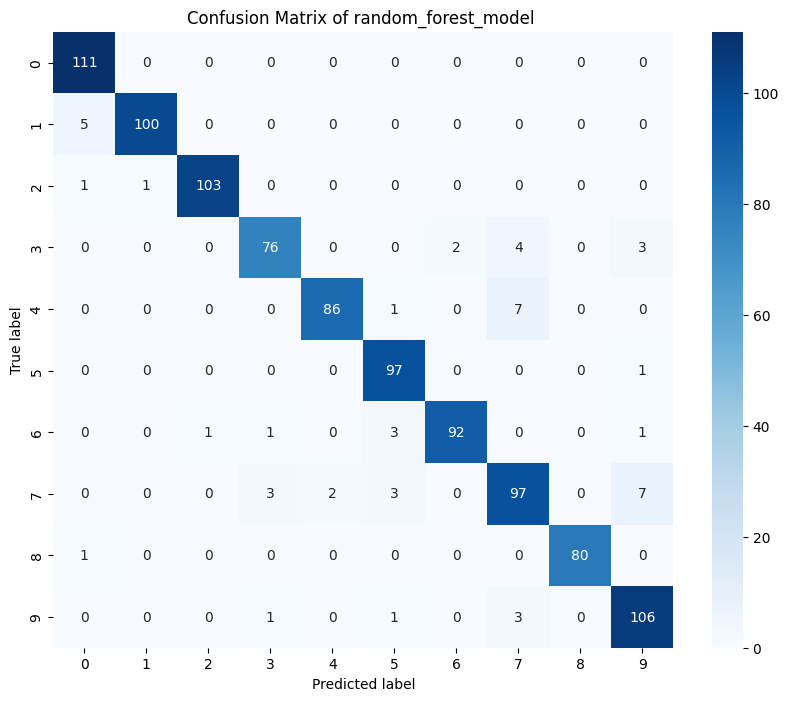

Precision: 0.95
Recall: 0.95
F1 Score: 0.95


In [76]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import joblib

# Assuming data is a tuple: (data_real_values, label)
# Ensure data is in the correct format
data_real_values, label = data

# Reshape data to 2D array (samples x features*2)
n_samples, n_features, _ = data_real_values.shape
data_real_values_2d = data_real_values.reshape(n_samples, n_features * 2)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values_2d)

# Apply PCA
pca = PCA(n_components=22)  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_scaled)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Train the classifier
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(data_real_values_train, label_train)

# Save the trained model
joblib.dump(clf, 'random_forest_model.pkl')

# Predict on test data
label_pred = clf.predict(data_real_values_test)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, label_pred)
conf_matrix = confusion_matrix(label_test, label_pred)
precision = precision_score(label_test, label_pred, average='weighted')
recall = recall_score(label_test, label_pred, average='weighted')
f1 = f1_score(label_test, label_pred, average='weighted')

print(f'Accuracy: {accuracy * 100:.2f}%')
#print(f'Confusion Matrix:\n{conf_matrix}')
#y_pred = model_to_train.predict(data_real_values_test)
#y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels
# Compute confusion matrix
#conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of random_forest_model ')
plt.show()
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


Epoch 1/50


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1107 - loss: 3.4672 - val_accuracy: 0.1912 - val_loss: 2.2102
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1693 - loss: 2.2117 - val_accuracy: 0.3413 - val_loss: 1.9634
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2302 - loss: 2.0146 - val_accuracy: 0.4487 - val_loss: 1.6111
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3036 - loss: 1.7944 - val_accuracy: 0.5700 - val_loss: 1.3634
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3682 - loss: 1.5896 - val_accuracy: 0.6637 - val_loss: 1.0655
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4822 - loss: 1.2961 - val_accuracy: 0.7462 - val_loss: 0.8985
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5111 - loss: 1.1796 - val_accuracy: 0.7275 - val_loss: 0.7810
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5836 - loss: 1.0339 - val_accuracy: 0.7663 - val_

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 95.00%


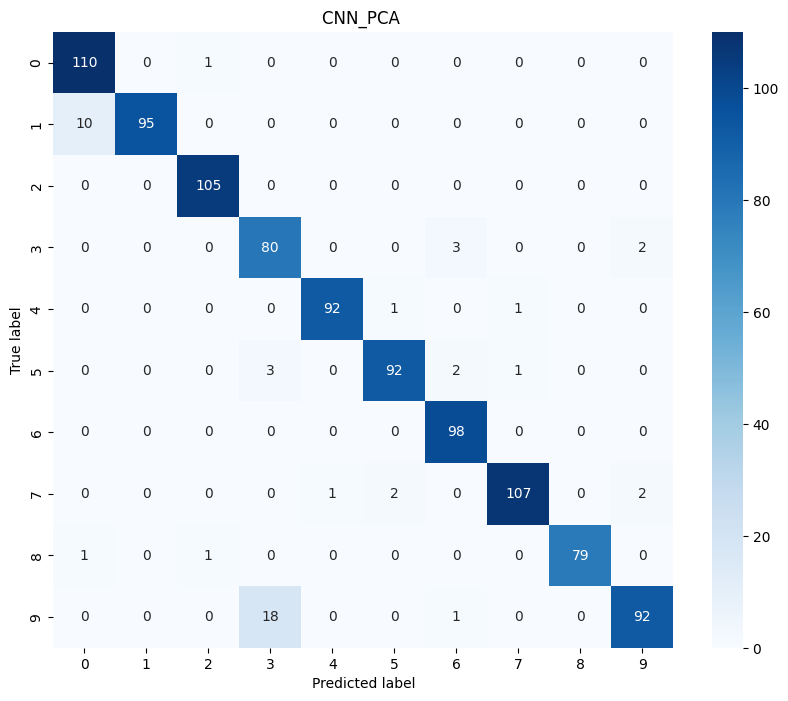

Precision: 0.95
Recall: 0.95
F1 Score: 0.95


In [96]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming data is a tuple: (data_real_values, label)
data_real_values, label = data

# Reshape data to 4D array (samples, height, width, channels)
n_samples, n_features, _ = data_real_values.shape
data_real_values_4d = data_real_values.reshape(n_samples, n_features, 2, 1)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values.reshape(-1, 2)).reshape(data_real_values.shape)

# Reshape the data into a 2D array
data_real_values_flattened = data_real_values_scaled.reshape(n_samples, -1)

# Apply PCA
pca = PCA(n_components=(22))  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_flattened)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Build the CNN model...
# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 1), activation='relu', input_shape=(22, 1, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# Reshape the training and test data to match the input shape of the CNN model
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 22, 1, 1)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 22, 1, 1)

# Train the model
model.fit(data_real_values_train_reshaped, label_train_categorical, batch_size=32, epochs=50, validation_split=0.2)

# Train the model
#model.fit(data_real_values_train, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)v



# Save the trained model
model.save('CNN_PCA_1_model.h5')
# load and evaluate a saved model\n",

# Obtain predictions on the test set
#label_pred = model.predict(data_real_values_test)
# Obtain predictions on the test set
#label_pred = model.predict(data_real_values_test_reshaped)

y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels
label_pred = model.predict(data_real_values_test_reshaped)

y_pred_classes = np.argmax(label_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)




# Predict on test data


# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')




print(f'Accuracy: {accuracy * 100:.2f}%')


# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('CNN_PCA ')
plt.show()
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')



Epoch 1/50


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 41s 387ms/step - accuracy: 0.1502 - loss: 2.2272 - val_accuracy: 0.3537 - val_loss: 1.6618
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.3431 - loss: 1.5795 - val_accuracy: 0.5312 - val_loss: 1.1215
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4930 - loss: 1.2543 - val_accuracy: 0.5537 - val_loss: 1.0292
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5996 - loss: 0.9333 - val_accuracy: 0.7038 - val_loss: 0.7142
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.6151 - loss: 0.9147 - val_accuracy: 0.7650 - val_loss: 0.6505
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7179 - loss: 0.6894 - val_accuracy: 0.8188 - val_loss: 0.5005
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7691 - loss: 0.5904 - val_accuracy: 0.8375 - val_loss: 0.4259
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7766 - loss: 0.5686 - val_accuracy: 0.8

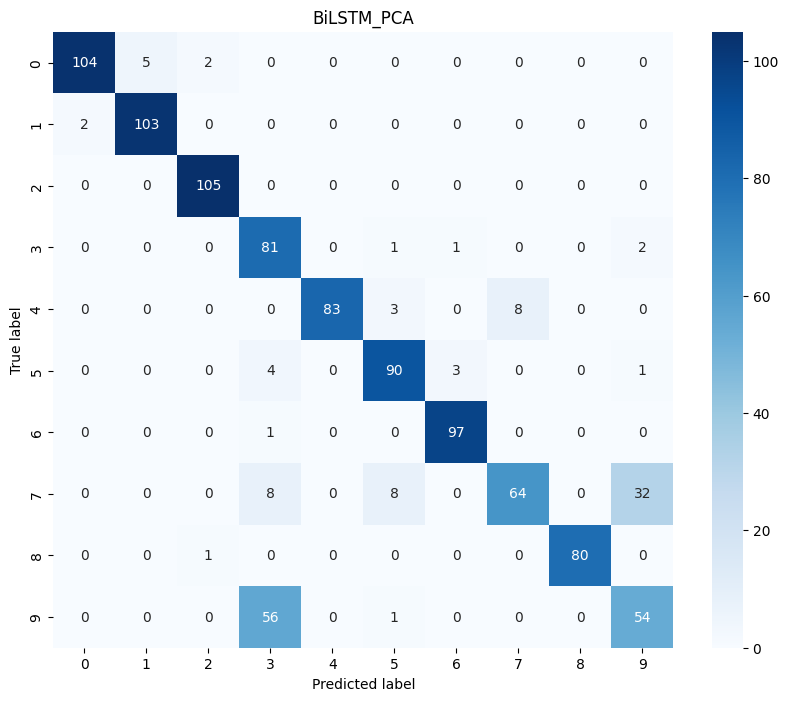

In [98]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming data is a tuple: (data_real_values, label)
data_real_values, label = data

# Reshape data to 4D array (samples, height, width, channels)
n_samples, n_features, _ = data_real_values.shape
data_real_values_4d = data_real_values.reshape(n_samples, n_features, 2, 1)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values.reshape(-1, 2)).reshape(data_real_values.shape)

# Reshape the data into a 2D array
data_real_values_flattened = data_real_values_scaled.reshape(n_samples, -1)

# Apply PCA
pca = PCA(n_components=(22))  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_flattened)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Reshape the training and test data to match the input shape of the BiLSTM model
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 22, 1)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 22, 1)

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(22, 1)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_real_values_train_reshaped, label_train_categorical, batch_size=32, epochs=50, validation_split=0.2)

# Predict on test data
label_pred = model.predict(data_real_values_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('BiLSTM_PCA')
plt.show()


In [36]:
data.shape

(5000, 7170)

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming data is a tuple: (data_real_values, label)
data_real_values, label = data

# Reshape data to 4D array (samples, height, width, channels)
n_samples, n_features, _ = data_real_values.shape
data_real_values_4d = data_real_values.reshape(n_samples, n_features, 2, 1)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values.reshape(-1, 2)).reshape(data_real_values.shape)

# Reshape the data into a 2D array
data_real_values_flattened = data_real_values_scaled.reshape(n_samples, -1)

# Apply PCA
pca = PCA(n_components=(22))  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_flattened)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Reshape the training and test data to match the input shape of the BiLSTM model
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 22, 1)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 22, 1)

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(22, 1)))
model.add(Dropout(0.5))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_real_values_train_reshaped, label_train_categorical, batch_size=32, epochs=500, validation_split=0.2)

# Predict on test data
label_pred = model.predict(data_real_values_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('BiLSTM_PCA')
plt.show()


ValueError: too many values to unpack (expected 2)

Epoch 1/50


/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.1314 - loss: 3.3121 - val_accuracy: 0.1150 - val_loss: 2.3063
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.2315 - loss: 2.3206 - val_accuracy: 0.3150 - val_loss: 1.8157
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3283 - loss: 1.8542 - val_accuracy: 0.4688 - val_loss: 1.3129
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3786 - loss: 1.5818 - val_accuracy: 0.5437 - val_loss: 1.0351
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4320 - loss: 1.3809 - val_accuracy: 0.4075 - val_loss: 1.3572
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4736 - loss: 1.2824 - val_accuracy: 0.5537 - val_loss: 0.9924
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.5407 - loss: 1.1017 - val_accuracy: 0.6963 - val_loss: 0.7358
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5707 - loss: 1.0108 - val_accuracy: 0.298

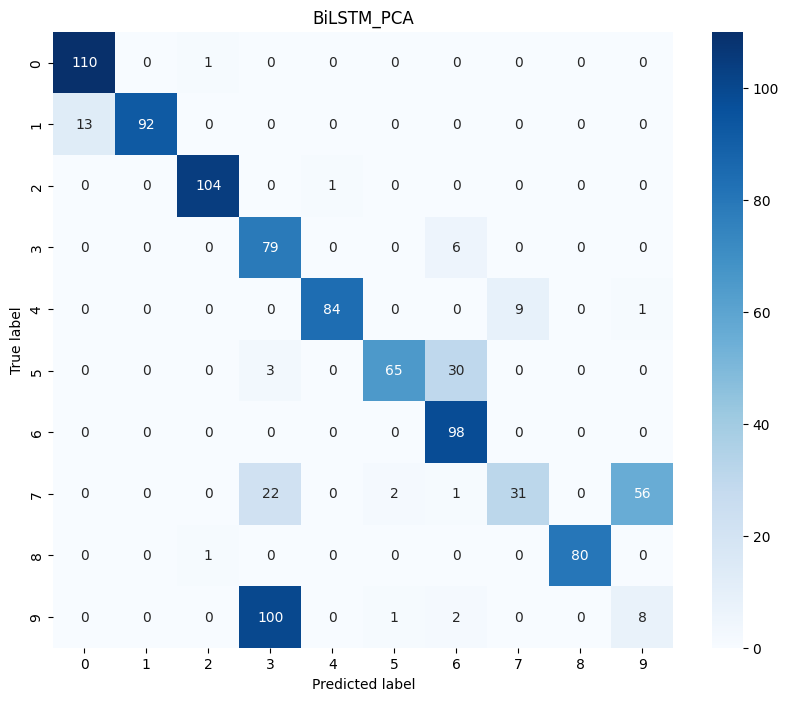

In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

# Assuming data is a tuple: (data_real_values, label)
data_real_values, label = data

# Reshape data to 4D array (samples, height, width, channels)
n_samples, n_features, _ = data_real_values.shape
data_real_values_4d = data_real_values.reshape(n_samples, n_features, 2, 1)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values.reshape(-1, 2)).reshape(data_real_values.shape)

# Reshape the data into a 2D array
data_real_values_flattened = data_real_values_scaled.reshape(n_samples, -1)

# Apply PCA
pca = PCA(n_components=(22))  # Adjust n_components as needed
data_real_values_pca = pca.fit_transform(data_real_values_flattened)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_pca, label, test_size=0.2, random_state=42
)

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Reshape the training and test data to match the input shape of the BiLSTM model
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 22, 1)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 22, 1)

# Build the BiLSTM model
model = Sequential()
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(22, 1)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Bidirectional(LSTM(64)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(10, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_real_values_train_reshaped, label_train_categorical, batch_size=32, epochs=50, validation_split=0.2)

# Predict on test data
label_pred = model.predict(data_real_values_test_reshaped)
y_pred_classes = np.argmax(label_pred, axis=1)

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Calculate evaluation metrics
accuracy = accuracy_score(label_test, y_pred_classes)
precision = precision_score(label_test, y_pred_classes, average='weighted')
recall = recall_score(label_test, y_pred_classes, average='weighted')
f1 = f1_score(label_test, y_pred_classes, average='weighted')

# Print evaluation metrics
print(f'Accuracy: {accuracy * 100:.2f}%')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('BiLSTM_PCA')
plt.show()


In [64]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Assuming data is a tuple: (data_real_values, label)
data_real_values, label = data

# Reshape data to 4D array (samples, height, width, channels)
n_samples, n_features, _ = data_real_values.shape
data_real_values_4d = data_real_values.reshape(n_samples, n_features, 2, 1)

# Standardize the data
scaler = StandardScaler()
data_real_values_scaled = scaler.fit_transform(data_real_values.reshape(-1, 2)).reshape(data_real_values.shape)

# Convert labels to categorical
#label_categorical = to_categorical(label)

# Split the data
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(
    data_real_values_scaled, label, test_size=0.2, random_state=42
)

# Reshape the standardized data back to 4D array
data_real_values_train = data_real_values_train.reshape(-1, n_features, 2, 1)
data_real_values_test = data_real_values_test.reshape(-1, n_features, 2, 1)

# Build the CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 2), activation='relu', input_shape=(n_features, 2, 1)))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Conv2D(64, kernel_size=(3, 1), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 1)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

# Convert labels to categorical
label_train_categorical = to_categorical(label_train, num_classes=10)

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
model.fit(data_real_values_train, label_train_categorical, batch_size=32, epochs=100, validation_split=0.2)




/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.1012 - loss: 3.9270 - val_accuracy: 0.1238 - val_loss: 2.3014
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 155ms/step - accuracy: 0.1029 - loss: 2.3019 - val_accuracy: 0.1300 - val_loss: 2.3000
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 160ms/step - accuracy: 0.1052 - loss: 2.2961 - val_accuracy: 0.2225 - val_loss: 2.2262
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.1414 - loss: 2.2435 - val_accuracy: 0.1975 - val_loss: 2.1250
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.1597 - loss: 2.1941 - val_accuracy: 0.2500 - val_loss: 2.0319
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 152ms/step - accuracy: 0.1606 - loss: 2.1601 - val_accuracy: 0.2025 - val_loss: 2.0041
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.1668 - loss: 2.1378 - val_accuracy: 0.1975 - val_loss: 1.9593
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 154ms/step - accuracy: 0.1570 -

In [31]:
spectrogram.shape

(5000, 129, 58)

In [49]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(spectrogram)
imaginary_part = np.imag(spectrogram)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 2D CNN
# For 2D CNN, you can directly use the data_normalized as input
# Reshape for the channel dimension (add 1 for the channel dimension)
data_real_values = data_normalized.reshape((data_normalized.shape[0], data_normalized.shape[1], data_normalized.shape[2], 2))




In [61]:
data_real_values.shape

(5000, 129, 58, 2)

In [56]:
data_normalized.shape[2]


58

In [51]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)



In [52]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout
from sklearn.model_selection import train_test_split



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
data_lstm = np.transpose(data_normalized, 2)
# Define the BiLSTM model
model = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(data_lstm)),
    Dropout(0.5),  # Add dropout for regularization
    Bidirectional(LSTM(64)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Assuming your input data is named 'data_real_values_train' and 'data_real_values_test'

# Reshape the input data to remove the last dimension
data_real_values_train_reshaped = data_real_values_train.reshape(-1, 129, 58)
data_real_values_test_reshaped = data_real_values_test.reshape(-1, 129, 58)

# Fit the model with the reshaped input data
train_history = model.fit(
    data_real_values_train_reshaped, label_train, 
    validation_data=(data_real_values_test_reshaped, label_test),
    epochs=200, batch_size=32,
    callbacks=callbacks,
)


# Fit the model
train_history = model.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=200, batch_size=32,
    callbacks=callbacks,
)


In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(data_normalized.shape[1], data_normalized.shape[2], 2)),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.5),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),

    #Add Dense layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Dropout for regularization
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])




# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=200, batch_size=32,
    callbacks=callbacks,
)


In [48]:
import numpy as np

# Assuming 'data' is your complex-valued data
# Normalize each dimension separately
real_part = np.real(spectrogram)
imaginary_part = np.imag(spectrogram)

# Normalize the real and imaginary parts separately
real_part_normalized = (real_part - np.mean(real_part)) / np.std(real_part)
imaginary_part_normalized = (imaginary_part - np.mean(imaginary_part)) / np.std(imaginary_part)

# Concatenate the real and imaginary parts along the channel dimension
data_normalized = np.stack((real_part_normalized, imaginary_part_normalized), axis=-1)

# Reshape the data for 2D CNN
# For 2D CNN, you can directly use the data_normalized as input
# Reshape for the channel dimension (add 1 for the channel dimension)
data_cnn = data_normalized.reshape((data_normalized.shape[0], data_normalized.shape[1], data_normalized.shape[2], 2))




In [ ]:
# Reshape the data for 2D BiLSTM
# For 2D BiLSTM, you need to transpose the last two dimensions
data_lstm = np.transpose(data_normalized, (0, 2, 1))

# Now data_cnn and data_lstm can be used as input for 2D CNN and 2D BiLSTM models, respectively

In [37]:
data_real_values.shape
data_real_values.shape[1]

129

In [28]:
data_real_values.shape[1]

7170

In [19]:
data_real_values.shape

(5000, 7170, 2)

In [38]:
np.unique(label)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [71]:
input_data=data_real_values

In [79]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU, SimpleRNN

In [42]:
model_to_train.save('cnn4_model.h5')

In [43]:
# load and evaluate a saved model\n",
from numpy import loadtxt
from tensorflow.keras.models import load_model

# load model\n",
model = load_model('cnn4_model.h5')
# summarize model.\n",
#model.summary()

# evaluate the model\n",
score = model.evaluate(data_real_values_test, label_test, verbose=0)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))
   

compile_metrics: 93.10%


In [ ]:
# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute confusion matrix
conf_matrix = confusion_matrix(label_test, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix of CNN4')
plt.show()

In [45]:
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Obtain predictions on the test set
y_pred = model_to_train.predict(data_real_values_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

# Compute overall precision, recall, and F1-score
precision, recall, f1_score, _ = precision_recall_fscore_support(label_test, y_pred_classes, average='weighted')

print("Overall Precision:", precision)
print("Overall Recall:", recall)
print("Overall F1-Score:", f1_score)


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Overall Precision: 0.9394776880852437
Overall Recall: 0.931
Overall F1-Score: 0.9254366310776557


In [ ]:
data_real_values_test.shape

In [ ]:
Spectrogram

In [22]:
data=data_real_values

In [ ]:
%pip install librosa

In [ ]:
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height*width)
print(spectrogram_data_reshaped.shape)


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, RobustScaler

#scaling=StandardScaler()
r_scaling =RobustScaler()

r_scaling.fit(spectrogram_data_reshaped)

# Use fit and transform method 
Scaled_data= r_scaling.transform(spectrogram_data_reshaped)

# Set the n_components=3
principal=PCA(n_components=50)
principal.fit(Scaled_data)
pca_spectrogram_data =principal.transform(Scaled_data)
total_samples, width = pca_spectrogram_data.shape
pca_spectrogram_data = pca_spectrogram_data.reshape(total_samples, 1, width)
    
# # Check the dimensions of data after PCA
print("Previous shape one sample is", spectrogram_data_reshaped[:, 0].shape)
print("New shape of one one sample is", pca_spectrogram_data[:,0].shape)

In [ ]:
# # VISUALISE ORIGINAL SAMPLE
# test_sample = spectrogram_data_reshaped[0]
# plt.figure(figsize=(6, 3.2))
# plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
# plt.colorbar()
# plt.title('ColorMap')
# plt.show()

In [ ]:
plt.figure(figsize=(10,10))
plt.scatter(pca_spectrogram_data[:,0], pca_spectrogram_data[:,1], c=spectrogram_label, cmap='plasma')
plt.xlabel('pc1')
plt.ylabel('pc2')

In [ ]:
pca_spectrogram_data[0].shape

In [ ]:
#SOME PREPROCESSING

data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)



In [ ]:
#binary_spectrogram_labels = np.where(spectrogram_label <=19, 0, 1)

# data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(spectrogram_data, 
#                                                                     label, 
#                                                                     test_size=0.2, 
#                                                                     shuffle= True)

In [ ]:
spectrogram_data.shape
np.unique(binary_spectrogram_labels)

In [ ]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


# cnn_model2 = Sequential()
# cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
# cnn_model2.add(MaxPooling2D(pool_size=2, padding='same'))
# #cnn_model2.add(Dropout(0.2))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
# cnn_model2.add(Flatten())
# cnn_model2.add(Dense(64, activation='relu'))
# cnn_model2.add(Dense(1, activation='sigmoid'))

#cnn_model2.summary()

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, width)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
# cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(1, activation='sigmoid'))

# cnn_model.summary()



In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    # EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# Compile the model
model_to_train.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_values_train, label_train, 
    validation_data=(data_real_values_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)


In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

model_to_train = cnn_model

loss1 = keras.losses.BinaryFocalCrossentropy()
loss2 = keras.losses.BinaryCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
#optimizer = keras.optimizers.RMSprop(learning_rate=0.01) # https://keras.io/api/optimizers/rmsprop/
optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(pca_spectrogram_data, binary_spectrogram_labels, 
                                   epochs=10, batch_size=20)

In [ ]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(label)
predictions = model_to_train.predict(spectrogram_data_reshaped)
predictions = np.argmax(predictions, axis=1).reshape(predictions.shape[0], 1)
confusion_matrix = metrics.confusion_matrix(spectrogram_label, predictions)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()
precision_recall_fscore_support(spectrogram_label, predictions, average='macro')



In [ ]:
# Optionally, you can visualize a spectrogram for one sample
#plt.figure(figsize=(10, 4))
#librosa.display.specshow(librosa.amplitude_to_db(spectrograms[0], ref=np.max), sr=44100, hop_length=512, x_axis='time', y_axis='log')
#plt.colorbar(format='%+2.0f dB')
#plt.title('Spectrogram')
#plt.show()

In [31]:
spectrograms.shape

(5000, 2, 1025, 15)

In [32]:
spectrograms.shape[1]

2

In [33]:
data_real=spectrograms

In [34]:
#SOME PREPROCESSING

data_real.shape
data_real_train, data_real_test, label_train, label_test = train_test_split(data_real, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [35]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import librosa

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense, BatchNormalization

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# Assuming your input data is stored in a variable called 'X_train', 'X_test', 'y_train', 'y_test'

# Define CNN model
def create_cnn_model(input_shape):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (1, 1), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(64, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(Dropout(0.3))
    model.add(layers.Conv2D(128, (1, 1), activation='relu'))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D((1, 1)))
    model.add(layers.Flatten())
    model.add(Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    return model

# Initialize model
input_shape = (2,1025, 15)  # Input shape (channels, frequency bins, time bins)
cnn_model = create_cnn_model(input_shape)


# Model to train
model_to_train = cnn_model

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001),
    #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]
tf.keras.backend.get_session().run(tf.global_variables_initializer())

# Compile the model
model_to_train.compile(optimizer='RMSprop', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Fit the model
train_history = model_to_train.fit(
    data_real_train, label_train, 
    validation_data=(data_real_test, label_test),
    epochs=50, batch_size=32,
    callbacks=callbacks,
)



Train on 4000 samples, validate on 1000 samples
Epoch 1/50
3968/4000 [============================>.] - ETA: 0s - loss: 14.3659 - acc: 0.0968

FailedPreconditionError: Error while reading resource variable RMSprop/lr from Container: localhost. This could mean that the variable was uninitialized. Not found: Container localhost does not exist. (Could not find resource: localhost/RMSprop/lr)
	 [[node RMSprop/lr/Read/ReadVariableOp (defined at <ipython-input-37-a9ede0bfde32>:44)  = ReadVariableOp[dtype=DT_FLOAT, _device="/job:localhost/replica:0/task:0/device:CPU:0"](RMSprop/lr)]]

Caused by op 'RMSprop/lr/Read/ReadVariableOp', defined at:
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 193, in _run_module_as_main
    "__main__", mod_spec)
  File "/opt/conda/envs/project/lib/python3.6/runpy.py", line 85, in _run_code
    exec(code, run_globals)
  File "/opt/conda/envs/project/lib/python3.6/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/opt/conda/envs/project/lib/python3.6/site-packages/traitlets/config/application.py", line 664, in launch_instance
    app.start()
  

In [ ]:
import numpy as np

# Assuming your input data is named 'data'
data = data

# Step 1: Square each element of the input data
squared_data = np.square(data)

# Step 2: Calculate the mean of the squared values
mean_squared = np.mean(squared_data)

# Step 3: Take the square root of the mean to obtain the RMS value
rms_value = np.sqrt(mean_squared)

# Step 4: Normalize the input data by dividing by the RMS value
normalized_data = data / rms_value
